# Training — experiments as data

**Reads:** `data/<DATASET>/split/`, `configs/augment.json` (optional) · **Writes:** `runs/<run_id>/`.

All training logic lives in `thai_char_cnn.train.fit`; this notebook only says *which* runs to
make and reads their results. Each experiment is one row of overrides on a shared `BASE`.

A run is cached under a hash of its full config, seed, `split_id` and the training code itself
(`code_hash`, over the modules in `src/thai_char_cnn/` that decide what a run produces). Rerunning
the notebook loads finished runs instead of retraining them, so adding a row trains only that row,
and editing the training code invalidates every cached run, so a loaded result always comes from
the code on disk.

Two switches, both off by default:

| env var | effect |
| --- | --- |
| `RETRAIN=1` | ignore the cache and retrain every row (overwrites its run) |
| `VERIFY=1` | §5 retrains the first run into a scratch folder and checks it matches the cached one |
| `EPOCHS=n` | smoke run with `n` epochs (a separate run, since epochs are part of the hash) |

### What the score is, and isn't

- The score is **val macro-F1 over validated classes**: per-class F1 averaged with equal weight, over
  the classes `03_split` could give enough val images. Accuracy is shown too, but with this
  imbalance it mostly reflects the ten biggest classes.
- Val is chosen **by writer**, so it measures unseen handwriting. It is also used for early
  stopping and for choosing between experiments, so it is optimistic. The instructor's hidden test
  set is the real test, and nothing here is called "test".
- Classes flagged *not validated* are trained on, but nothing measures them. They are listed below.

## 1 · Setup and data check

**What:** load the current split and check it passed its own self-checks, then show what the
training pipeline actually feeds the model, augmentation included.

**Why the montage is here:** the augmentation preview (`05_augment_preview.py`) is deferred. Until
it exists, this is the only look at what augmentation does to the glyphs. Augmentation is tiered
per class (`thai_char_cnn.augment.TIER_GROUPS`): robust glyphs get the full range, hook/loop pairs,
ascender/descender letters, marks and the า/ๅ pair get progressively less. Each row's label shows
the character and its tiers.

In [1]:
import json
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib import font_manager
from PIL import Image

from thai_char_cnn.augment import build_train_transform, load_augment_config
from thai_char_cnn.data import SplitData
from thai_char_cnn.metrics import top_confused
from thai_char_cnn.paths import CONFIGS, FONT, RAW, SPLIT_DIR
from thai_char_cnn.preprocess import letterbox
from thai_char_cnn.train import DEFAULT_CONFIG, code_hash, fit, load_runs

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
font_manager.fontManager.addfont(str(FONT))
THAI = font_manager.FontProperties(fname=str(FONT), size=16)

split_run = json.loads((SPLIT_DIR / "run.json").read_text(encoding="utf-8"))
SPLIT_ID = split_run["split_id"]
failed = [k for k, v in split_run["checks"].items() if v != "PASS"]
assert not failed, f"03_split self-checks failed: {failed}"

aug_path = CONFIGS / "augment.json"
AUG = load_augment_config(aug_path)
print(f"split_id     : {SPLIT_ID}   ({split_run['generated_at']})")
print(f"augmentation : {'configs/augment.json' if aug_path.exists() else 'defaults (no configs/augment.json yet)'}")
print(f"               overrides: profiles={AUG.profiles or '{}'}, tiers={AUG.tiers or '{}'}")
print(f"device       : {'cuda — ' + torch.cuda.get_device_name() if torch.cuda.is_available() else 'cpu'}")

data = SplitData(DEFAULT_CONFIG["img_size"], DEFAULT_CONFIG["preprocess"])
print(f"\ntrain images : {len(data.idx['train']):,}")
print(f"val images   : {len(data.idx['val']):,}")
print(f"pixel mean/std (train only): {data.pixel_mean:.4f} / {data.pixel_std:.4f}")
classes = data.classes
print(f"classes      : {classes.status.value_counts().to_dict()}")
print(f"not validated: {', '.join(f'{r.folder} {r.character}' for r in classes[classes.status == 'not_validated'].itertuples())}")
print(f"weak (val<5) : {', '.join(f'{r.folder} {r.character}' for r in classes[classes.status == 'weak'].itertuples())}")

split_id     : 50c201baf3b1   (2026-09-24T16:50:20+00:00)
augmentation : configs/augment.json
               overrides: profiles={}, tiers={'จ': [4], 'ด': [4], 'ต': [4], 'ว': [5], 'า': [5], 'ใ': [5]}
device       : cuda — NVIDIA GeForce RTX 4070

train images : 48,400
val images   : 11,996
pixel mean/std (train only): 0.5647 / 0.4445
classes      : {'validated': 56, 'not_validated': 11, 'weak': 5}
not validated: 163 ฃ, 177 ฑ, 196 ฤ, 204 ฬ, 206 ฮ, 214 ึ, 244 ๔, 245 ๕, 246 ๖, 247 ๗, 249 ๙
weak (val<5) : 189 ฝ, 207 ฯ, 225 แ, 234 ๊, 248 ๘


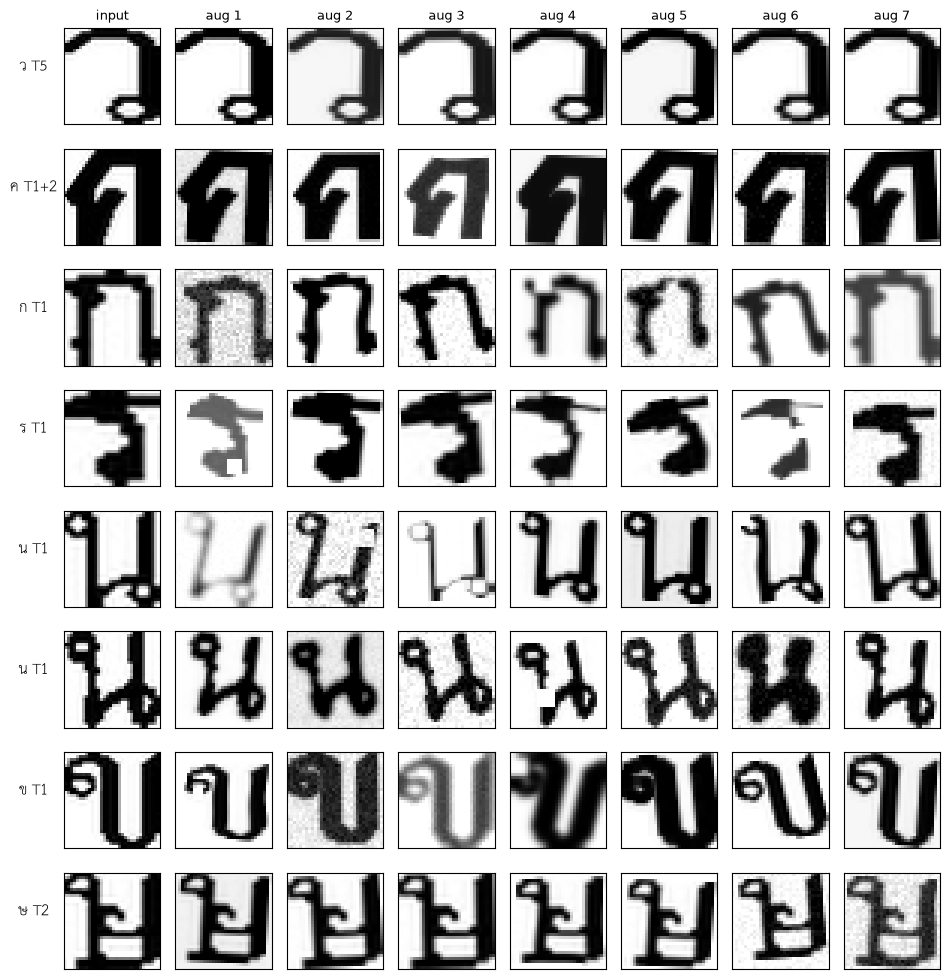

In [2]:
# first column: the model input as-is; the rest: independent draws of the train transform
N_ROWS, N_DRAWS = 8, 7
torch.manual_seed(0)
rng = np.random.default_rng(0)
pick = rng.choice(data.idx["train"], N_ROWS, replace=False)
tf = build_train_transform(AUG, classes.character.tolist())
TIERS = AUG.resolved_tiers()
fig, ax = plt.subplots(N_ROWS, N_DRAWS + 1, figsize=(1.2 * (N_DRAWS + 1), 1.25 * N_ROWS))
for r, j in enumerate(pick):
    px = data.pixels[j]
    for c in range(N_DRAWS + 1):
        img = px if c == 0 else tf(px, int(data.y[j]))
        ax[r, c].imshow(img[0], cmap="gray", vmin=0, vmax=255)
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])
    ch = classes.character.iloc[int(data.y[j])]
    ax[r, 0].set_ylabel(f"{ch} T{'+'.join(map(str, TIERS[ch]))}", fontproperties=THAI, rotation=0, labelpad=22)
ax[0, 0].set_title("input", fontsize=9)
for c in range(1, N_DRAWS + 1):
    ax[0, c].set_title(f"aug {c}", fontsize=9)
plt.tight_layout()
plt.show()

## 2 · Experiment table

`BASE` is shared by every run; `EXPERIMENTS` maps a name to the overrides that make it different.
Anything not listed takes `thai_char_cnn.train.DEFAULT_CONFIG`.

The default input is square `stretch`, which beat aspect-preserving `letterbox` on every seed in this
frozen-split ablation, before and after the data audit. `letterbox` stays as its control, with the
same model and optimization settings. `stretch+augment` adds tiered augmentation (`augment=True`,
see §1); it is still tied with plain `stretch`.

Rows are kept only while they answer an open question. Retired experiments, and the results that
retired them, are recorded in `reports/training-decisions.md`. Each
configuration uses three seeds because small single-seed gaps are not decision-quality evidence.

`EPOCHS`, `RETRAIN` and `VERIFY` come from the environment (see the top of the notebook), so a
command-line run can set them without editing the notebook.

In [3]:
BASE = dict(epochs=int(os.environ.get("EPOCHS", DEFAULT_CONFIG["epochs"])))
SEEDS = [42, 137, 271]
RETRAIN = os.environ.get("RETRAIN") == "1"
VERIFY = os.environ.get("VERIFY") == "1"

EXPERIMENTS = {
    "stretch": {},
    "letterbox": dict(preprocess="letterbox"),
    "stretch+augment": dict(augment=True),
}

table = pd.DataFrame({name: DEFAULT_CONFIG | BASE | ov for name, ov in EXPERIMENTS.items()}).T
varying = [c for c in table.columns if table[c].astype(str).nunique() > 1]
print(f"shared      : {({k: v for k, v in (DEFAULT_CONFIG | BASE).items() if k not in varying})}")
print(f"seeds       : {SEEDS}")
print(f"code_hash   : {code_hash()}")
print(f"RETRAIN={RETRAIN}  VERIFY={VERIFY}")
table[varying] if varying else table[[]].assign(overrides="none — baseline only")

shared      : {'model': 'small_cnn', 'width': 32, 'dropout': 0.3, 'use_geometry': False, 'img_size': 32, 'sampler': 'none', 'epochs': 40, 'batch_size': 256, 'lr': 0.003, 'weight_decay': 0.0005, 'warmup_epochs': 1, 'label_smoothing': 0.0, 'patience': 8, 'seed': 42, 'amp': True}
seeds       : [42, 137, 271]
code_hash   : b850cc0c6bb2
RETRAIN=False  VERIFY=False


,preprocess,augment
stretch,stretch,False
letterbox,letterbox,False
stretch+augment,stretch,True


## 3 · Train (or load)

One loop. A finished run is loaded from `runs/`; anything new is trained, and with `RETRAIN=1`
everything is. On the RTX 3060 a baseline epoch takes about two seconds.

In [4]:
RUN_DIRS = {}
for name, overrides in EXPERIMENTS.items():
    for seed in SEEDS:
        RUN_DIRS.setdefault(name, []).append(fit(BASE | overrides | dict(name=name, seed=seed),
                                                 force=RETRAIN))

[stretch] ep   1  loss 1.204  val loss 0.132  acc 0.9712  macro-F1 0.8336  (12.6s)


[stretch] ep   2  loss 0.102  val loss 0.204  acc 0.9355  macro-F1 0.8348  (1.2s)


[stretch] ep   3  loss 0.058  val loss 0.051  acc 0.9861  macro-F1 0.9820  (1.2s)


[stretch] ep   4  loss 0.046  val loss 0.041  acc 0.9873  macro-F1 0.9811  (1.2s)


[stretch] ep   5  loss 0.038  val loss 0.051  acc 0.9839  macro-F1 0.9792  (1.2s)


...

[stretch+augment] ep  36  loss 0.008  val loss 0.035  acc 0.9914  macro-F1 0.9896  (3.3s)


[stretch+augment] ep  37  loss 0.008  val loss 0.035  acc 0.9913  macro-F1 0.9894  (3.2s)


[stretch+augment] ep  38  loss 0.008  val loss 0.035  acc 0.9912  macro-F1 0.9894  (3.3s)


[stretch+augment] ep  39  loss 0.007  val loss 0.034  acc 0.9916  macro-F1 0.9895  (3.3s)


[stretch+augment] ep  40  loss 0.007  val loss 0.034  acc 0.9916  macro-F1 0.9894  (3.3s)
[stretch+augment] best epoch 36: val macro-F1 0.9896 -> runs\5a894a836e71


## 4 · Leaderboard

Ranked by val macro-F1 over validated classes, mean ± standard deviation across seeds. Only runs in
the current experiment table are ranked, and those are by construction on the current `split_id`
and `code_hash`. Other runs on disk are listed below as a record, not compared, with the reason: a
different split means a different val set, and different code means a different pipeline.

In [5]:
runs = load_runs()
current_ids = {p.name for dirs in RUN_DIRS.values() for p in dirs}
cur = runs[runs.run_id.isin(current_ids)].copy()
name_of = {p.name: n for n, dirs in RUN_DIRS.items() for p in dirs}
cur["experiment"] = cur.run_id.map(name_of)

board = (cur.groupby("experiment")
         .agg(seeds=("seed", "size"), macro_f1=("val_macro_f1", "mean"), macro_f1_sd=("val_macro_f1", "std"),
              macro_f1_all=("val_macro_f1_all", "mean"), val_acc=("val_acc", "mean"),
              best_epoch=("best_epoch", "mean"), minutes=("train_time_s", lambda s: s.sum() / 60))
         .sort_values("macro_f1", ascending=False).round(4))
print(f"split {SPLIT_ID} · headline = macro-F1 over {int((classes.status == 'validated').sum())} validated classes\n")
display(board)

other = runs[~runs.run_id.isin(current_ids)]
if len(other):
    other = other.assign(reason=np.select(
        [other.split_id != SPLIT_ID, other["cfg.code_hash"] != code_hash()],
        ["older split", "older code"], "not in the experiment table"))
    print(f"\nnot ranked: {len(other)} other run(s) on disk")
    display(other[["run_id", "name", "reason", "split_id", "cfg.code_hash", "cfg.epochs", "seed", "val_macro_f1"]])

split 50c201baf3b1 · headline = macro-F1 over 56 validated classes



,seeds,macro_f1,macro_f1_sd,macro_f1_all,val_acc,best_epoch,minutes
experiment,,,,,,,
stretch+augment,3,0.9901,0.0005,0.9846,0.9911,31.6667,6.7917
stretch,3,0.9877,0.0022,0.9859,0.9898,14.0000,1.8633
letterbox,3,0.9876,0.0026,0.9860,0.9905,24.6667,2.3633



not ranked: 18 other run(s) on disk


,run_id,name,reason,split_id,cfg.code_hash,cfg.epochs,seed,val_macro_f1
1,032227b694ea,letterbox+geometry,older code,50c201baf3b1,c659a93abb00,40,271,0.987435
2,12f7fe739ce2,stretch,older code,50c201baf3b1,c659a93abb00,40,42,0.985350
3,2c337ec4df0b,letterbox,older code,50c201baf3b1,c659a93abb00,40,271,0.984686
5,44a1204bfdce,stretch,older code,50c201baf3b1,c659a93abb00,40,271,0.989605
6,44a25f9d54fa,stretch+augment,older code,50c201baf3b1,c6670c36538f,40,137,0.989931
7,451ac769c276,letterbox,older code,50c201baf3b1,c6670c36538f,40,271,0.984686
10,5ccd7cf10f27,letterbox+geometry,older code,50c201baf3b1,c659a93abb00,40,137,0.987673
12,70abdf875f9a,stretch,older code,50c201baf3b1,c659a93abb00,40,137,0.988026
13,75fad5c3f110,stretch,older code,50c201baf3b1,c6670c36538f,40,271,0.989605
14,79aac5aa2ef7,stretch+augment,older code,50c201baf3b1,c6670c36538f,40,42,0.990651


## 5 · Reproducibility check (`VERIFY=1`)

**What:** retrain the first run of the first experiment from scratch into a scratch folder and
compare it with the cached run: metrics, per-epoch history, every val prediction, and the weights.

**Why:** the cache is only trustworthy if training is deterministic. Seeds, cuDNN's deterministic
mode and seeded data-loader workers are meant to make it so; this measures whether they do.

**How to read it:**

- **exact** — identical weights. The cache is a faithful stand-in for retraining.
- **drift** — macro-F1 within 0.005. Expected after a change of GPU, driver, PyTorch/CUDA version
  or `num_workers`, which reorder floating-point work. Not a bug; worth a note.
- **mismatch** — a larger gap. Something the run hash doesn't capture changed; investigate before
  trusting any cached number.

It costs one extra training run, so it's off unless asked for.

In [6]:
DRIFT_TOL = 0.005
if not VERIFY:
    print("skipped (set VERIFY=1 to retrain and compare)")
else:
    ref_name = next(iter(EXPERIMENTS))
    ref = RUN_DIRS[ref_name][0]
    ref_cfg = BASE | EXPERIMENTS[ref_name] | dict(name=ref_name, seed=SEEDS[0])
    with tempfile.TemporaryDirectory() as tmp:
        new = fit(ref_cfg, data=data, runs_dir=Path(tmp), verbose=False)
        ma, mb = (json.loads((d / "metrics.json").read_text(encoding="utf-8")) for d in (ref, new))
        ha, hb = (pd.read_csv(d / "history.csv") for d in (ref, new))
        pa, pb = (pd.read_csv(d / "val_predictions.csv") for d in (ref, new))
        sa, sb = (torch.load(d / "model.pt", weights_only=False)["state_dict"] for d in (ref, new))
    same_id = new.name == ref.name
    dw = max(float((sa[k].float() - sb[k].float()).abs().max()) for k in sa)
    df1 = abs(ma["val_macro_f1"] - mb["val_macro_f1"])
    hcols = ["train_loss", "val_loss", "val_macro_f1"]
    verdict = ("exact" if same_id and dw == 0 else "drift" if same_id and df1 <= DRIFT_TOL else "mismatch")

    print(f"retrained {ref_name!r} (run {ref.name}) from scratch in {mb['train_time_s']:.0f}s")
    print(f"  same run id          : {same_id}")
    print(f"  val macro-F1         : cached {ma['val_macro_f1']:.6f}  retrained {mb['val_macro_f1']:.6f}")
    print(f"  best epoch           : cached {ma['best_epoch']}  retrained {mb['best_epoch']}")
    print(f"  history max |diff|   : {float((ha[hcols] - hb[hcols]).abs().max().max()) if len(ha) == len(hb) else 'length differs'}")
    print(f"  val predictions diff : {int((pa.pred_idx != pb.pred_idx).sum())} of {len(pa):,}")
    print(f"  weights max |diff|   : {dw}")
    print(f"\nverdict: {verdict.upper()}")
    assert verdict != "mismatch", "retraining does not reproduce the cached run"

skipped (set VERIFY=1 to retrain and compare)


## 6 · Deep dive

Everything below reads the run named by `FOCUS` (its first seed). Change `FOCUS` to look at another
experiment; nothing else needs editing.

- **Per-class F1**, weakest first. Grey bars are *weak* classes (fewer than 5 val images); their F1 is
  close to noise. Not-validated classes have no val images and are absent.
- **Top confused pairs.** These feed the next ruling pass: a pair confused in both directions is
  either genuinely similar glyphs or a labelling problem, and only looking at the images says which.
- **Error gallery**: the most confident mistakes, which are where label errors tend to hide.

stretch  run 38ac8d193033  split 50c201baf3b1
  val macro-F1 (validated classes) : 0.9853
  val macro-F1 (all with val)      : 0.9833
  val accuracy                     : 0.9868
  best epoch 6 of 14 run, 28s, 296,168 params


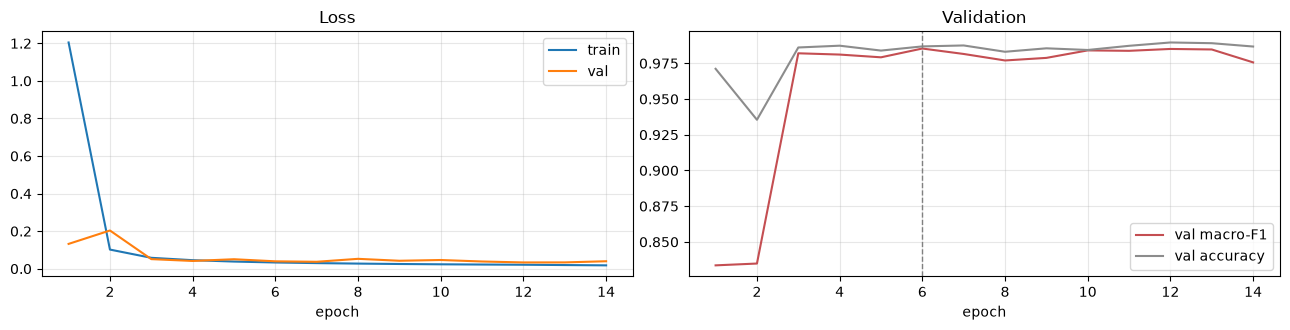

In [7]:
FOCUS = "stretch"
run_dir = RUN_DIRS[FOCUS][0]
m = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
hist = pd.read_csv(run_dir / "history.csv")
pc = pd.read_csv(run_dir / "per_class.csv", keep_default_na=False, na_values=[""])
cm = np.load(run_dir / "confusion.npy")
preds = pd.read_csv(run_dir / "val_predictions.csv")

print(f"{FOCUS}  run {m['run_id']}  split {m['split_id']}")
print(f"  val macro-F1 (validated classes) : {m['val_macro_f1']:.4f}")
print(f"  val macro-F1 (all with val)      : {m['val_macro_f1_all']:.4f}")
print(f"  val accuracy                     : {m['val_acc']:.4f}")
print(f"  best epoch {m['best_epoch']} of {m['epochs_run']} run, {m['train_time_s']:.0f}s, {m['n_params']:,} params")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(hist.epoch, hist.train_loss, label="train")
ax[0].plot(hist.epoch, hist.val_loss, label="val")
ax[0].set(title="Loss", xlabel="epoch")
ax[0].legend()
ax[1].plot(hist.epoch, hist.val_macro_f1, color="#C44E52", label="val macro-F1")
ax[1].plot(hist.epoch, hist.val_acc, color="#8C8C8C", label="val accuracy")
ax[1].axvline(m["best_epoch"], ls="--", c="gray", lw=1)
ax[1].set(title="Validation", xlabel="epoch")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

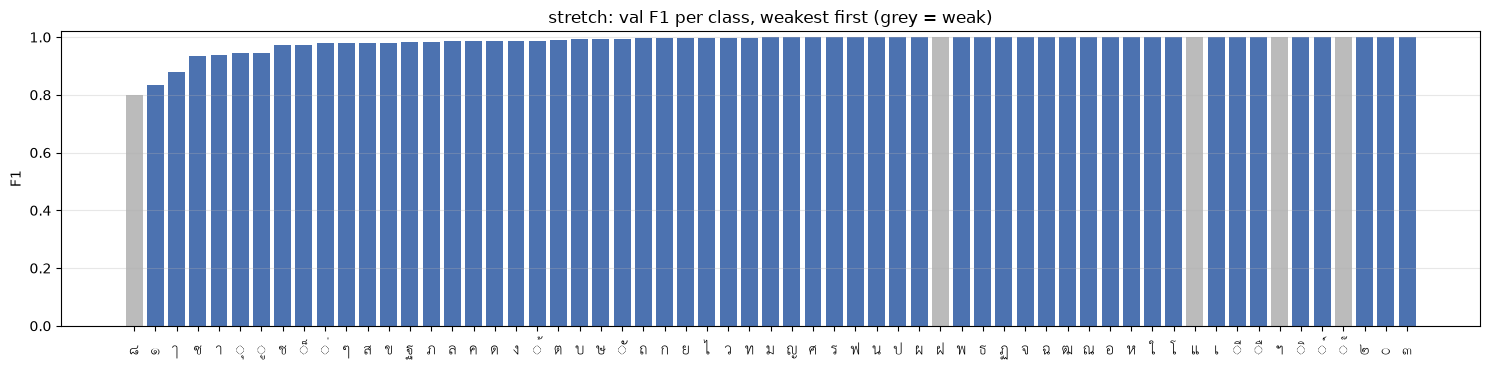

weakest 12 classes:


,class_idx,folder,character,status,train_n,support,precision,recall,f1
70,70,248,๘,weak,24,2,0.667,1.000,0.800
63,63,241,๑,validated,39,7,1.000,0.714,0.833
55,55,229,ๅ,validated,1069,405,0.949,0.820,0.879
8,8,171,ซ,validated,224,46,0.955,0.913,0.933
43,43,210,า,validated,3067,713,0.904,0.972,0.936
48,48,216,ุ,validated,137,17,0.895,1.000,0.944
49,49,217,ู,validated,116,26,0.897,1.000,0.945
7,7,170,ช,validated,873,165,0.976,0.970,0.973
57,57,231,็,validated,99,19,1.000,0.947,0.973
58,58,232,่,validated,290,46,0.978,0.978,0.978


In [8]:
shown = pc[pc.support > 0].sort_values("f1")
fig, ax = plt.subplots(figsize=(15, 3.8))
ax.bar(range(len(shown)), shown.f1, color=np.where(shown.status == "weak", "#BBBBBB", "#4C72B0"))
ax.set_xticks(range(len(shown)))
ax.set_xticklabels(shown.character, fontproperties=THAI)
ax.set(title=f"{FOCUS}: val F1 per class, weakest first (grey = weak)", ylabel="F1", ylim=(0, 1.02))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("weakest 12 classes:")
shown.head(12)[["class_idx", "folder", "character", "status", "train_n", "support", "precision", "recall", "f1"]].round(3)

In [9]:
ch = classes.set_index("class_idx")
tc = top_confused(cm, 15)
tc["true"] = tc.true_idx.map(lambda i: f"{ch.folder[i]} {ch.character[i]}")
tc["predicted"] = tc.pred_idx.map(lambda i: f"{ch.folder[i]} {ch.character[i]}")
tc["reverse_count"] = [int(cm[p, t]) for t, p in zip(tc.true_idx, tc.pred_idx, strict=True)]
tc[["true", "predicted", "count", "share_of_true", "reverse_count"]].round(3)

,true,predicted,count,share_of_true,reverse_count
0,229 ๅ,210 า,72,0.178,18
1,210 า,229 ๅ,18,0.025,72
2,202 ส,197 ล,10,0.034,0
3,180 ด,164 ค,7,0.016,3
4,233 ้,209 ั,4,0.021,1
5,171 ซ,170 ช,4,0.087,2
6,167 ง,181 ต,4,0.027,0
7,162 ข,186 บ,4,0.014,0
8,209 ั,217 ู,3,0.004,0
9,164 ค,180 ด,3,0.009,7


val errors: 158 of 11,996 — the 32 most confident:


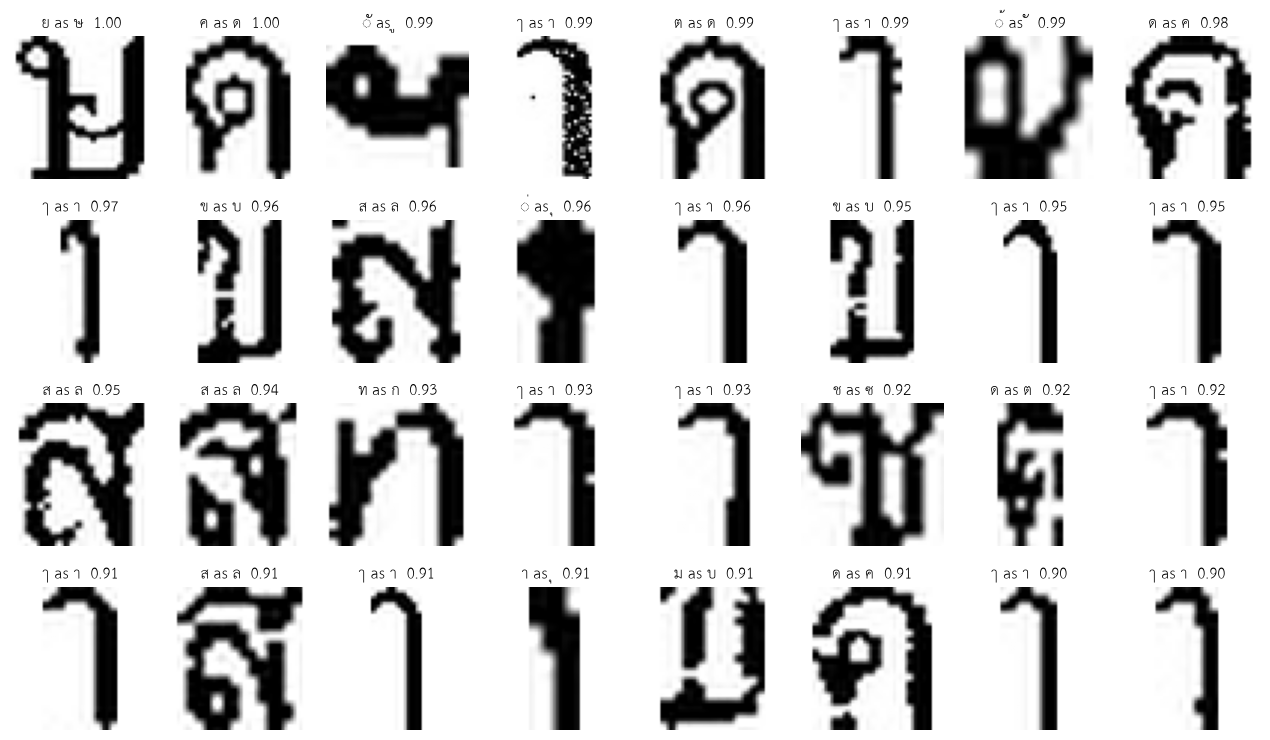

,path,writer_id,true,pred,p_pred,p_true
5835,194/be_018tg_7_188.jpg,be_018,194,201,0.9985,0.0004
1994,180/be_006sg_3_439.jpg,be_006,164,180,0.9961,0.0019
8753,209/bc_001tg_8_283.jpg,bc_001,209,217,0.9939,0.0013
11468,229/be_018tg_2_15.jpg,be_018,229,210,0.9918,0.0066
2332,181/be_002sg_9_37.jpg,be_002,181,180,0.9906,0.0088
10332,210/be_018sg_6_36.jpg,be_018,229,210,0.9898,0.0093
8949,209/be_002tg_10_162.jpg,be_002,233,209,0.9887,0.0030
1906,180/bc_020tg_3_428.jpg,bc_020,180,164,0.9844,0.0050
9904,210/be_002sg_7_321.jpg,be_002,229,210,0.9739,0.0250
480,162/bc_020tg_3_145.jpg,bc_020,162,186,0.9633,0.0072


In [10]:
N_ERR = 32
err = preds[preds.true_idx != preds.pred_idx].sort_values("p_pred", ascending=False).head(N_ERR)
print(f"val errors: {int((preds.true_idx != preds.pred_idx).sum()):,} of {len(preds):,} — the {len(err)} most confident:")
cols = 8
fig, ax = plt.subplots(int(np.ceil(len(err) / cols)), cols, figsize=(1.6 * cols, 1.9 * np.ceil(len(err) / cols)),
                       squeeze=False)
for a in ax.ravel():
    a.axis("off")
for a, r in zip(ax.ravel(), err.itertuples(), strict=False):
    with Image.open(RAW / r.path) as im:
        a.imshow(letterbox(im.convert("L"), 48), cmap="gray", vmin=0, vmax=255)
    a.set_title(f"{ch.character[r.true_idx]} as {ch.character[r.pred_idx]}  {r.p_pred:.2f}", fontproperties=THAI)
plt.tight_layout()
plt.show()
err.assign(true=err.true_idx.map(ch.folder), pred=err.pred_idx.map(ch.folder))[
    ["path", "writer_id", "true", "pred", "p_pred", "p_true"]].head(12)